## 2D Probability vs. Weight Scaling

Import utils

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *

#### Option 1: Weight Scaling

 &emsp; 1.1. Build net<br>

In [2]:
#############################
#          Params           #
#############################
#np.random.seed(seed=187)

N_L0_E = 90000
N_L0_I = 90000
N_L1_E = 1

N = (N_L0_E + N_L0_I, N_L1_E)
n = int((N[0] / 2) ** (1 / 2))          
sig = 0.0001
K = 1

sig_0_E = 0.03
sig_0_I = 0.09 
sig_00 =  0.005  


p_0 = 1

w_00  =  1.0/(N_L0_E*np.pi*((sig_00)**2)*p_0) * 0.5
w_0_E =  1.0 / (N_L0_E * np.pi * (sig_0_E ** 2) * p_0) 
w_0_I = -1.0 / (N_L0_I * np.pi * (sig_0_I ** 2) * p_0) 


#############################
#        Create Net         #
#############################

#layer 0
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

#layer 1

xy_E = np.random.rand(N_L1_E, 2)

xy_E[:,0] = xy_E[:,1] = 0.5 

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)

net.append([xy_lig_E, xy_rec_E])

#############################
#    Create Connectivity    #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0]               


prob_00 = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L0_I, sig_00)          
B_00 = sample_bernoulli_sparse(prob_00, K)
W_00 = (w_00 * B_00).tocsr()

B_L0E_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E), K)
B_L0I_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I), K)
W_0_E_block = (w_0_E * B_L0E_L1E).tocsr()
W_0_I_block = (w_0_I * B_L0I_L1E).tocsr()

W_0_E = W_0_E_block.tocsr()
W_0_I = (W_00 @ W_0_I_block).tocsr()



 &emsp; 1.2. Analyze net<br>

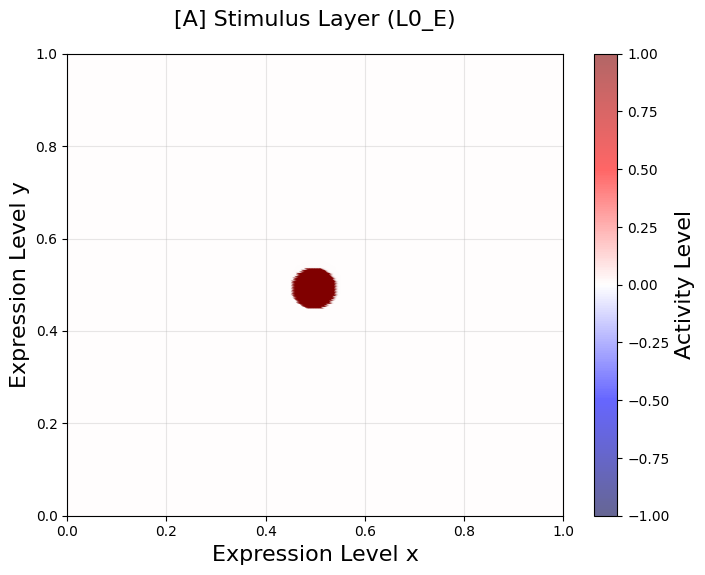

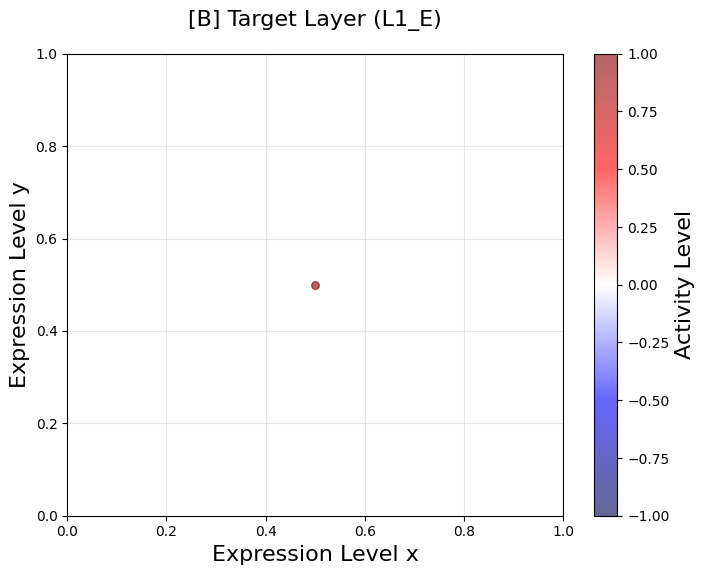

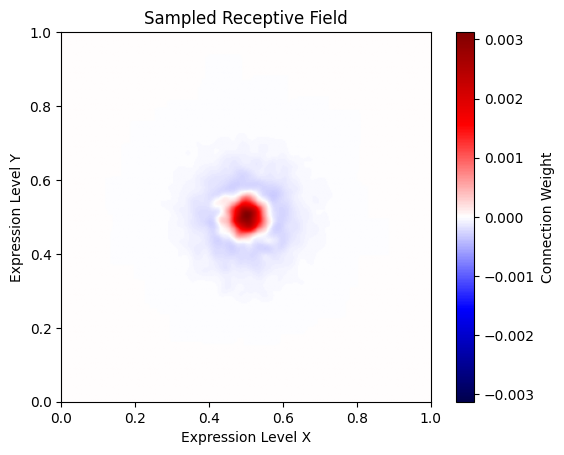

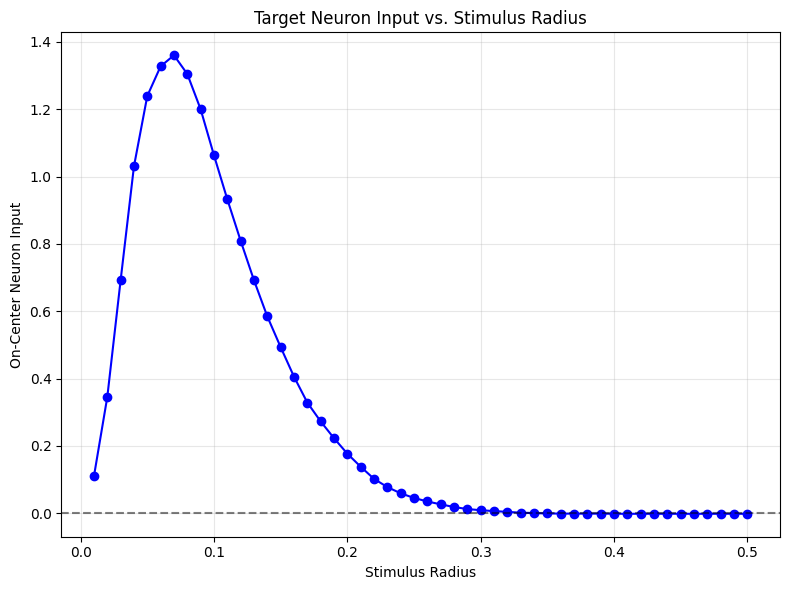

STA:   0%|          | 0/40 [00:00<?, ?batch/s]

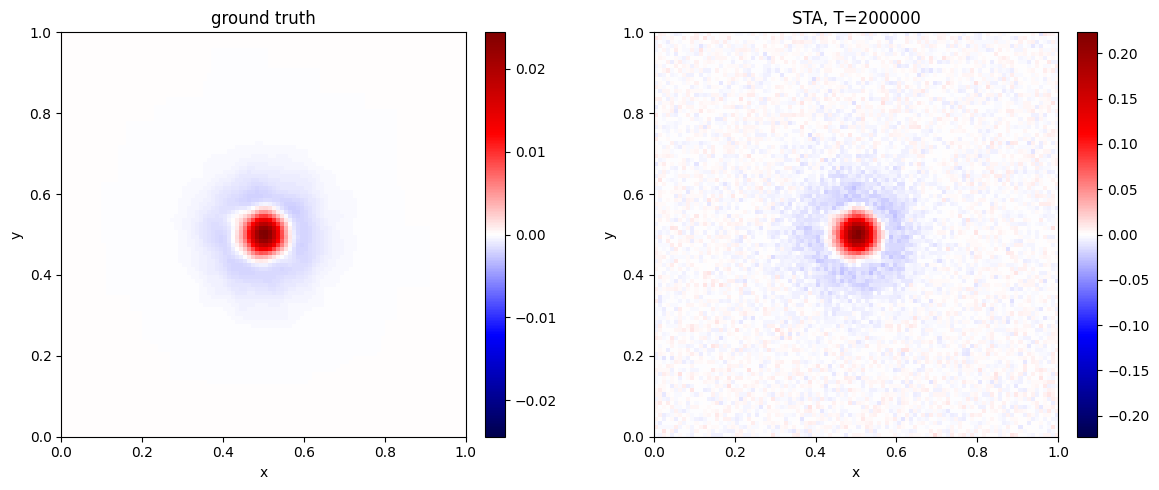

In [3]:
#############################
#    Verify Connectivity    #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)

W_0 = W_0_E + W_0_I

radius = sig_0_E * 1.5
cx = cy = 0.5

distances = np.sqrt((coords[:, 0] - cx) ** 2 + (coords[:, 1] - cy) ** 2)
stim_indices = np.where(distances <= radius)[0]

I_0 = np.zeros(N_L0_E)
I_0[stim_indices] = 1

x_0 = l_vals_L0_E[:, 0]
y_0 = l_vals_L0_E[:, 1]

plot_stim_act(I_0, x_0, y_0, title='[A] Stimulus Layer (L0_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

I_1 = W_0.T.dot(ReLU(I_0))
x_1 = l_vals_L1_E[:, 0]
y_1 = l_vals_L1_E[:, 1]

plot_stim_act(I_1, x_1, y_1, title='[B] Target Layer (L1_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

#############################
#       Analytical RF       #
#############################

W_0_csc = W_0.tocsc()
W_eff = W_0_csc[:, center_idx].toarray().ravel()

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=3)    

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Sampled Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()

#############################
#        Radial Plot        #
#############################

radii = np.linspace(0.01, 0.5, 50)
activities = []

for r in radii:
    stim_indices_r = np.where(distances <= r)[0]
    
    I_0_r = np.zeros(N_L0_E)
    I_0_r[stim_indices_r] = 1
    
    I_1_r = W_0.T.dot(ReLU(I_0_r))
    activities.append(I_1_r[center_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#############################
#          STA RF           #
#############################

m, T, B = 100, 200000, 5000
blk = n // m
assert n % m == 0
rng = np.random.default_rng(0)

target_idx = 0                                  

dx       = 1.0 / (n - 1)
sig_blk  = (1.0 / m) / np.sqrt(12)
sig_k    = max(sig_blk, 0.5 * min(sig_0_E, sig_0_I))
sig_k_px = sig_k / dx


wE = np.asarray(W_0_E.tocsc()[:, target_idx].todense()).ravel()
wI = np.asarray(W_0_I.tocsc()[:, target_idx].todense()).ravel()
rf_true = (wE + wI).reshape(n, n)

f = gaussian_filter(rf_true, sig_k_px, mode='reflect').reshape(m, blk, m, blk).sum((1, 3)).ravel()

sta, rsum = np.zeros(m * m), 0.0
for _ in tqdm(range(T // B), desc="STA", unit="batch"):
    s = rng.standard_normal((B, m * m))
    r = np.maximum(s @ f, 0.0)
    sta  += r @ s
    rsum += r.sum()
sta = (sta / rsum).reshape(m, m)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, im, t in [(ax[0], f.reshape(m, m), 'ground truth'), (ax[1], sta, f'STA, T={T}')]:
    v = np.abs(im).max()
    h = a.imshow(im, cmap='seismic', vmin=-v, vmax=v, origin='lower', extent=[0, 1, 0, 1])
    a.set(title=t, xlabel='x', ylabel='y')
    fig.colorbar(h, ax=a, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

#### Option 2: Probability Scaling

 &emsp; 2.1. Build net<br>

In [4]:
#############################
#          Params           #
#############################
#np.random.seed(seed=187)

N_L0_E = 90000
N_L0_I = 90000
N_L1_E = 1

N = (N_L0_E + N_L0_I, N_L1_E)
n = int((N[0] / 2) ** (1 / 2))          
sig = 0.0001
K = 1

sig_0_E = 0.03
sig_0_I = 0.09
sig_00 =  0.005  


p_0 = 1
p_E = 1
p_I = 0.10


w_00  =  1.0/(N_L0_E*np.pi*((sig_00)**2)*p_0) * 0.5
w_0_E =  1.0 / (N_L0_E * np.pi * (sig_0_E ** 2) * p_0)
w_0_I = -w_0_E


#############################
#        Create Net         #
#############################

#layer 0
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

#layer 1

xy_E = np.random.rand(N_L1_E, 2)

xy_E[:,0] = xy_E[:,1] = 0.5 

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)

net.append([xy_lig_E, xy_rec_E])

#############################
#    Create Connectivity    #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0]               


prob_00 = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L0_I, sig_00)          
B_00 = sample_bernoulli_sparse(prob_00, K)
W_00 = (w_00 * B_00).tocsr()

P_L0E_L1E = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E) * p_E
P_L0I_L1E = compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I) * p_I

B_L0E_L1E = sample_bernoulli_sparse(P_L0E_L1E, K)
B_L0I_L1E = sample_bernoulli_sparse(P_L0I_L1E, K)
W_0_E_block = (w_0_E * B_L0E_L1E).tocsr()
W_0_I_block = (w_0_I * B_L0I_L1E).tocsr()

W_0_E = W_0_E_block.tocsr()
W_0_I = (W_00 @ W_0_I_block).tocsr()


 &emsp; 2.2. Analyze net<br>

Center index:0


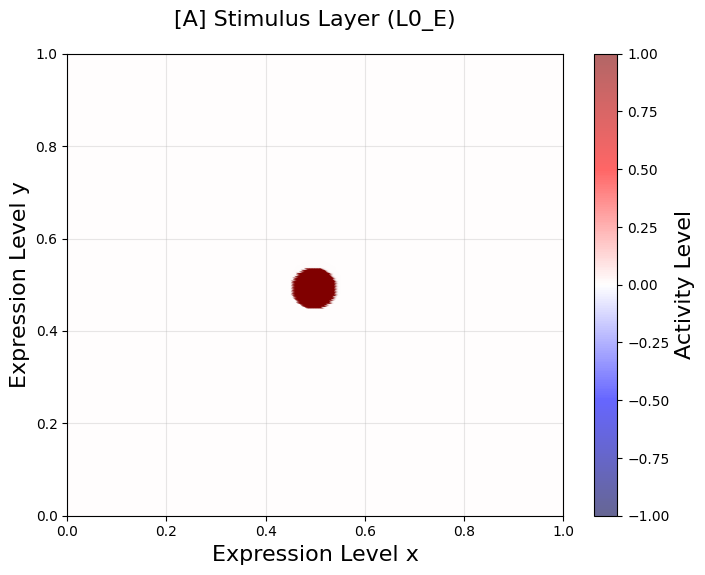

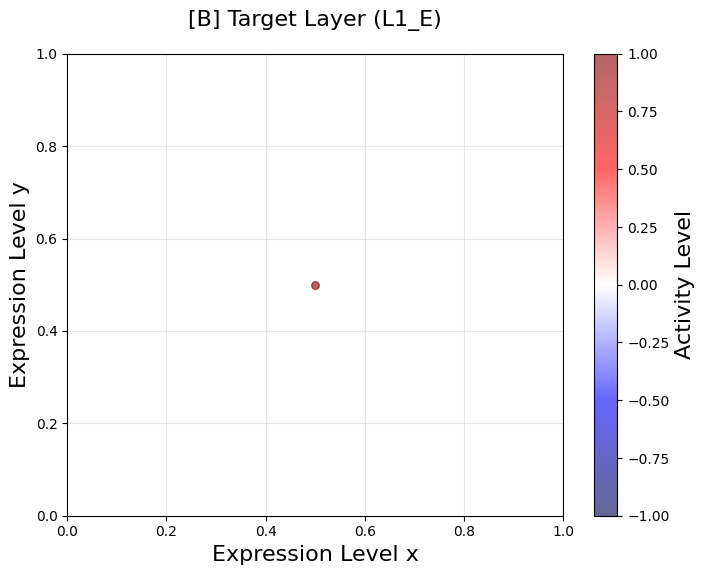

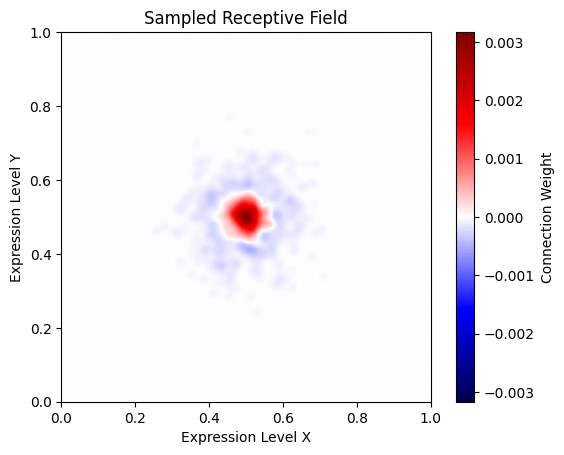

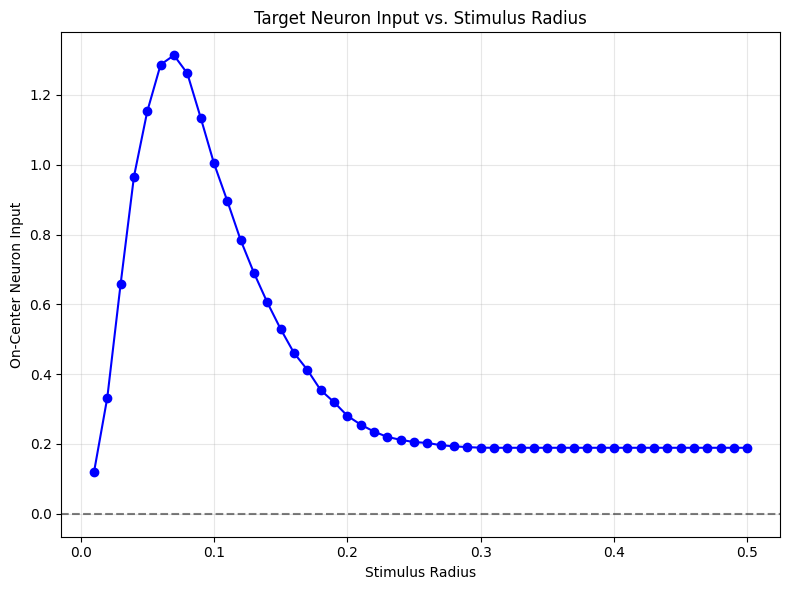

STA:   0%|          | 0/40 [00:00<?, ?batch/s]

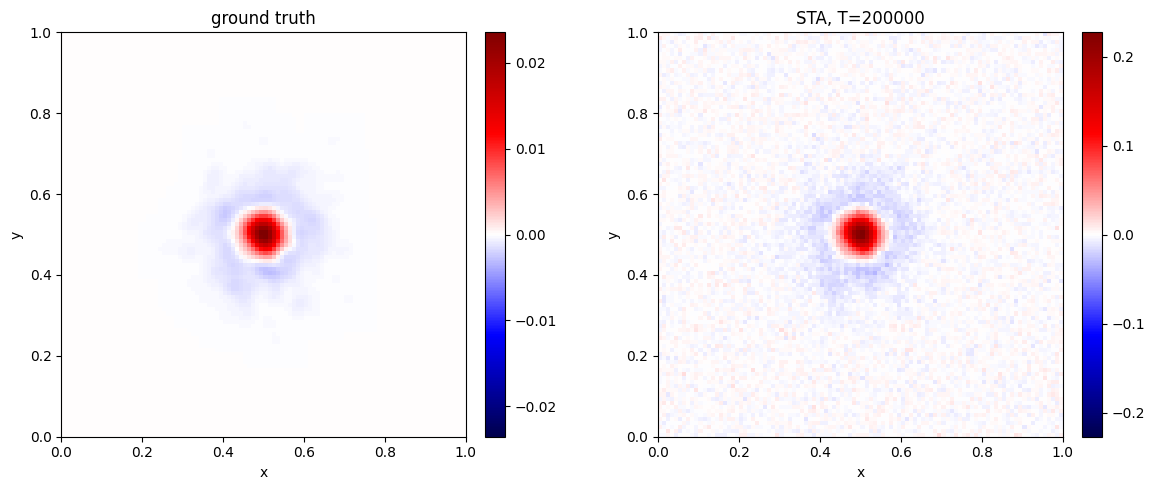

In [5]:
#############################
#    Verify Connectivity    #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
print(f'Center index:{center_idx}')

W_0 = W_0_E + W_0_I

radius = sig_0_E * 1.5
cx = cy = 0.5

distances = np.sqrt((coords[:, 0] - cx) ** 2 + (coords[:, 1] - cy) ** 2)
stim_indices = np.where(distances <= radius)[0]

I_0 = np.zeros(N_L0_E)
I_0[stim_indices] = 1

x_0 = l_vals_L0_E[:, 0]
y_0 = l_vals_L0_E[:, 1]

plot_stim_act(I_0, x_0, y_0, title='[A] Stimulus Layer (L0_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

I_1 = W_0.T.dot(ReLU(I_0))
x_1 = l_vals_L1_E[:, 0]
y_1 = l_vals_L1_E[:, 1]

plot_stim_act(I_1, x_1, y_1, title='[B] Target Layer (L1_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')


#############################
#       Analytical RF       #
#############################

W_0_csc = W_0.tocsc()
W_eff = W_0_csc[:, center_idx].toarray().ravel()

true_rf = W_eff.reshape(n, n)
true_rf = gaussian_filter(true_rf, sigma=3)    

vmax_true = np.max(np.abs(true_rf))
fig, ax = plt.subplots()
im0 = ax.imshow(true_rf[::-1, :], cmap='seismic', vmin=-vmax_true, vmax=vmax_true, extent=[0, 1, 0, 1])
ax.set_title('Sampled Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')
plt.colorbar(im0, ax=ax, label='Connection Weight')
plt.show()


#############################
#        Radial Plot        #
#############################

radii = np.linspace(0.01, 0.5, 50)
activities = []

for r in radii:
    stim_indices_r = np.where(distances <= r)[0]
    
    I_0_r = np.zeros(N_L0_E)
    I_0_r[stim_indices_r] = 1
    
    I_1_r = W_0.T.dot(ReLU(I_0_r))
    activities.append(I_1_r[center_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#############################
#          STA RF           #
#############################

m, T, B = 100, 200000, 5000
blk = n // m
assert n % m == 0
rng = np.random.default_rng(0)

target_idx = 0                                  

dx       = 1.0 / (n - 1)
sig_blk  = (1.0 / m) / np.sqrt(12)
sig_k    = max(sig_blk, 0.5 * min(sig_0_E, sig_0_I))
sig_k_px = sig_k / dx


wE = np.asarray(W_0_E.tocsc()[:, target_idx].todense()).ravel()
wI = np.asarray(W_0_I.tocsc()[:, target_idx].todense()).ravel()
rf_true = (wE + wI).reshape(n, n)

f = gaussian_filter(rf_true, sig_k_px, mode='reflect').reshape(m, blk, m, blk).sum((1, 3)).ravel()

sta, rsum = np.zeros(m * m), 0.0
for _ in tqdm(range(T // B), desc="STA", unit="batch"):
    s = rng.standard_normal((B, m * m))
    r = np.maximum(s @ f, 0.0)
    sta  += r @ s
    rsum += r.sum()
sta = (sta / rsum).reshape(m, m)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, im, t in [(ax[0], f.reshape(m, m), 'ground truth'), (ax[1], sta, f'STA, T={T}')]:
    v = np.abs(im).max()
    h = a.imshow(im, cmap='seismic', vmin=-v, vmax=v, origin='lower', extent=[0, 1, 0, 1])
    a.set(title=t, xlabel='x', ylabel='y')
    fig.colorbar(h, ax=a, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()